<a href="https://colab.research.google.com/github/AdityaWarrier2006/Machine-Learning-from-First-Principles/blob/main/LMS_Model_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The objective of this notebook is to demonstrate a basic linear regression model implemented from scratch using gradient descent. It predicts car drag values (Cd) based on synthetically generated car design features like roof angle, ride height, and underbody sweep. The notebook covers data loading, synthetic feature generation, feature normalization, implementation of cost and gradient descent functions, model training, and visualization of the learning process.

## Load Data from Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After mounting your Google Drive, you can access files. For example, to load the CSV file containing Cd values using pandas:

Drag Coefficient Dataset:

https://www.dropbox.com/scl/fi/2rtchqnpmzy90uwa9wwny/DrivAerNetPlusPlus_Cd_8k_Updated.csv?rlkey=vjnjurtxfuqr40zqgupnks8sn&st=6dx1mfct&e=1&dl=0

In [3]:
import pandas as pd

# Example: Replace 'your_file.csv' with the actual path to your CSV file in Google Drive
# For example: '/content/drive/MyDrive/your_folder/your_file.csv'
try:
    df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/DrivAerNet_Project/DrivAerNetPlusPlus_Cd_8k_Updated.csv')
    print("Successfully loaded data.")
    display(df.head())
except FileNotFoundError:
    print("Error: 'DrivAerNetPlusPlus_Cd_8k_Updated.csv' not found. Please update the path to your file.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data.


,ID,Drag_Value
0,F_D_WM_WW_0001,0.275833
1,F_D_WM_WW_0002,0.279602
2,F_D_WM_WW_0003,0.272837
3,F_D_WM_WW_0004,0.257712
4,F_D_WM_WW_0005,0.267890


### Understanding the Data

In [71]:
# length of our dataset
df.shape

(8121, 2)

In [72]:
# sample data
df.head(2)

,ID,Drag_Value
0,F_D_WM_WW_0001,0.275833
1,F_D_WM_WW_0002,0.279602


Statistics for 'Drag_Value'

In [73]:
mean_drag_value = df['Drag_Value'].mean()
variance_drag_value = df['Drag_Value'].var()
std_dev_drag_value = df['Drag_Value'].std()

print(f"Mean of Drag_Value: {mean_drag_value:.4f}")
print(f"Variance of Drag_Value: {variance_drag_value:.4f}")
print(f"Standard Deviation of Drag_Value: {std_dev_drag_value:.4f}")

Mean of Drag_Value: 0.2633
Variance of Drag_Value: 0.0004
Standard Deviation of Drag_Value: 0.0201


Histogram and Probability Density Function for 'Drag_Value'

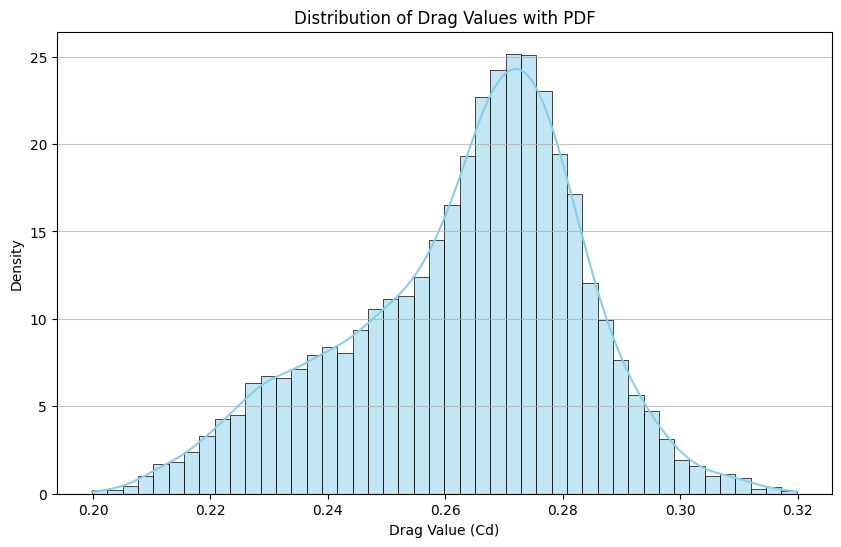

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Drag_Value'], kde=True, color='skyblue', stat='density', linewidth=0.5)
plt.title('Distribution of Drag Values with PDF')
plt.xlabel('Drag Value (Cd)')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.75)
plt.show()

Creating synthetic data for ride heights and roof heights

In [75]:
import pandas as pd
import numpy as np

# 1. Load the Drag Values file you already downloaded as df

# 2. Extract the IDs so our synthetic data matches perfectly
car_ids = df['ID'].values
num_cars = len(car_ids)

# 3. Generate synthetic geometric parameters using random normal distributions
# We will create 3 fake features: Roof_Angle, Ride_Height, and Underbody_Sweep
np.random.seed(42) # Keeps the random numbers the same every time you run it
synthetic_data = {
    'ID': car_ids,
    'Roof_Angle_Rad': np.random.normal(loc=0.25, scale=0.05, size=num_cars),
    'Ride_Height_mm': np.random.normal(loc=140, scale=15, size=num_cars),
    'Underbody_Sweep_Deg': np.random.normal(loc=5, scale=2, size=num_cars)
}

df_features = pd.DataFrame(synthetic_data)

# 4. Merge the synthetic features with your real Drag labels
df_merged = pd.merge(df_features, df, on='ID')

print("Dataset ready for Phase 2!")
print(df_merged.head())

Dataset ready for Phase 2!
               ID  Roof_Angle_Rad  Ride_Height_mm  Underbody_Sweep_Deg  \
0  F_D_WM_WW_0001        0.274836      122.296524             4.722865   
1  F_D_WM_WW_0002        0.243087      146.280569            -0.134872   
2  F_D_WM_WW_0003        0.282384      139.790402             4.105274   
3  F_D_WM_WW_0004        0.326151      134.997706             6.704030   
4  F_D_WM_WW_0005        0.238292      153.278845             8.127923   

   Drag_Value  
0    0.275833  
1    0.279602  
2    0.272837  
3    0.257712  
4    0.267890  


Normalizing all the inputs

In [76]:
# 1. Extract the features (X) and labels (y)
features = ['Roof_Angle_Rad', 'Ride_Height_mm', 'Underbody_Sweep_Deg']
X_raw = df_merged[features].values
y = df_merged['Drag_Value'].values.reshape(-1, 1) # y contains the predictions we want (Cd values)

# 2. Normalize the features (Crucial for Gradient Descent)
X_mean = np.mean(X_raw, axis=0)
X_std = np.std(X_raw, axis=0)
X_normalized = (X_raw - X_mean) / X_std

# 3. Add a column of ones to X for the y-intercept (theta_0)
m = len(y)
x = np.c_[np.ones((m, 1)), X_normalized] # we're adding a col of 1s to accout for the bias term

In [77]:
x

array([[ 1.        ,  0.49810274, -1.19351899, -0.1390977 ],
       [ 1.        , -0.13183677,  0.40893087, -2.58296013],
       [ 1.        ,  0.64787905, -0.02469771, -0.44979932],
       ...,
       [ 1.        , -0.22509996,  0.10043037, -0.8724438 ],
       [ 1.        ,  0.01579234,  2.00263007, -0.3725589 ],
       [ 1.        ,  1.13653229, -0.11574448, -1.86002659]])

In [78]:
y

array([[0.27583307],
       [0.27960169],
       [0.27283728],
       ...,
       [0.24597662],
       [0.23115762],
       [0.25454801]])

## Writing the Learning Algorithm

Function to determine how close the predctions are to actual

In [105]:
def compute_cost(x, y, theta):
  m = len(y)
  preds = x.dot(theta)
  cost = (1/2*m)*np.sum(np.square(preds - y))
  return cost

Stochastic Gradient Descent Method

In [106]:
def gradient_descent(x, y, theta, alpha, iterations):
# theta = weights, alpha = learning rate
  m = len(y)
  cost_history = np.zeros(iterations)

  for i in range(iterations):
    preds = x.dot(theta)
    error = preds - y

    # partial derivative
    gradients = (1/m) * x.T.dot(error)

    # update weights
    theta = theta - alpha*gradients
    cost_history[i] = compute_cost(x, y, theta)

  return theta, cost_history

### Training

In [107]:
np.random.seed(42)
theta_initial = np.random.randn(x.shape[1],1)
theta_initial

array([[ 0.49671415],
       [-0.1382643 ],
       [ 0.64768854],
       [ 1.52302986]])

Set hyperparameters

In [108]:
alpha = 0.01  # learning rate
iterations = 500

Update the weights

In [109]:
theta_final, cost_history = gradient_descent(x, y, theta_initial, alpha, iterations)

Plot the learning curve

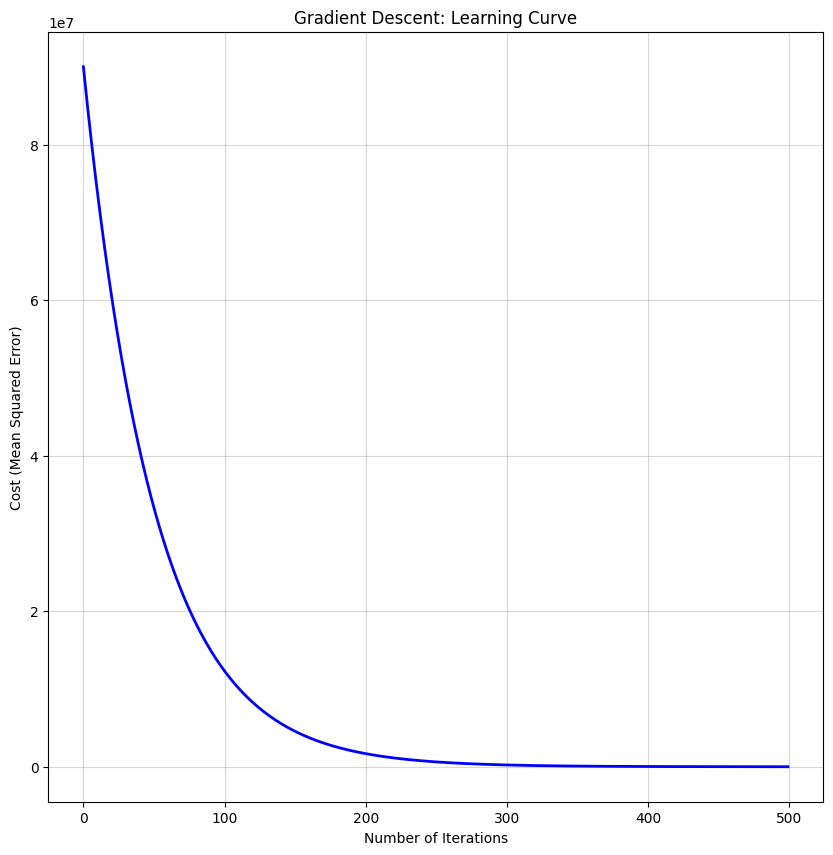

In [110]:
plt.figure(figsize=(10, 10))
plt.plot(range(iterations), cost_history, color='blue', linewidth=2)
plt.title('Gradient Descent: Learning Curve')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost (Mean Squared Error)')
plt.grid(True, alpha=0.5)
plt.show()

In [111]:
print("Final Optimized Weights:\n", theta_final)

Final Optimized Weights:
 [[ 0.26478994]
 [-0.00122802]
 [ 0.00430654]
 [ 0.01047154]]


In [112]:
x.dot(theta_final)

array([[0.25758175],
       [0.23966535],
       [0.25917788],
       ...,
       [0.25636304],
       [0.2694937 ],
       [0.24341846]])

In [113]:
y

array([[0.27583307],
       [0.27960169],
       [0.27283728],
       ...,
       [0.24597662],
       [0.23115762],
       [0.25454801]])